# How is the SequenceMatrix paper being cited?

A first look at the citation corpus we assembled for
[issue #127](https://github.com/gaurav/taxondna/issues/127). The anchor paper is
**Vaidya, Lohman & Meier (2011),** *"SequenceMatrix: concatenation software for
the fast assembly of multi-gene datasets with character set and codon
information"*, *Cladistics* 27(2): 171–180
([doi:10.1111/j.1096-0031.2010.00329.x](https://doi.org/10.1111/j.1096-0031.2010.00329.x),
OpenAlex `W2131473084`).

This notebook is the **read-only, show-the-numbers** companion to the data
pipeline. It loads the flat table the pipeline produced and renders:

1. a bar chart of citations per year since publication,
2. the top-10 journals and top-10 authors,
3. a word cloud of the citing-paper titles.

All of the collection and methodology lives in
[`citations/README.md`](README.md); this notebook only *reads* the cached
output, so running it never touches a network API.

## Where the data came from

We are looking at **every citing work OpenAlex knows about — not just the recent
ones.** The pull uses the filter `cites:W2131473084` and walks the full
cursor-paginated result set, so the corpus spans **2010–2026 (2,509 works)**, the
entire 15-year life of the paper. That is about **84% of the 2,986 citations
Google Scholar reports**; the ~480-paper gap is the long tail of theses,
proceedings, and regional journals OpenAlex does not index. For trend analysis
that recall is fine — see the discussion in
[`README.md`](README.md#anchor-record).

The numbers below come from a small, idempotent pipeline (each script caches its
upstream responses to disk, so re-runs are cheap and offline):

| Step | Script | What it does |
| --- | --- | --- |
| 1 | [`scripts/fetch_openalex_citing.py`](scripts/fetch_openalex_citing.py) | Pull every citing work from the OpenAlex API into `data/openalex/raw/page_*.json` |
| 2 | [`scripts/build_citing_works.py`](scripts/build_citing_works.py) | Flatten the raw pages into one record per paper → `data/openalex/citing_works.jsonl` |
| 3 | [`scripts/analyze_phase2.py`](scripts/analyze_phase2.py) | Derive the analysis table **`data/openalex/citing_works.csv`** (this notebook's input) and the [`phase2_metadata.md`](phase2_metadata.md) digest |

Two further steps enrich the picture but are **not used by this notebook**:
[`scripts/extract_cz_comentions.py`](scripts/extract_cz_comentions.py) cross-checks
the [CZ Software Mentions](https://doi.org/10.5061/dryad.6wwpzgn2c) corpus, and
[`scripts/build_fulltext_coverage.py`](scripts/build_fulltext_coverage.py) measures
how much of the corpus is reachable as free full text
(→ [`data/fulltext/coverage.csv`](data/fulltext/coverage.csv)). Each data
subdirectory has its own `README.md` documenting schema, license, and source
citations.

To reproduce from scratch: `cd citations && cp .env.example .env` (add a free
OpenAlex key), `uv sync`, then run steps 1–3 in order.

## Load the analysis table

`citing_works.csv` is one row per citing paper. Multi-valued columns
(`author_names`, `institution_names`, `topic_displays`, `software_comentions`, …)
are `; `-joined strings, which we split on demand. We only need a handful of
columns here.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve paths relative to this notebook so it runs from anywhere.
HERE = Path.cwd()
CSV = HERE / "data" / "openalex" / "citing_works.csv"
assert CSV.exists(), f"Run the pipeline first; missing {CSV}"

PAPER_YEAR = 2011  # SequenceMatrix was published in Cladistics in 2011.

df = pd.read_csv(CSV)
df["publication_year"] = pd.to_numeric(df["publication_year"], errors="coerce").astype("Int64")

print(f"{len(df):,} citing works, {df['publication_year'].min()}–{df['publication_year'].max()}")
df[["publication_year", "title", "venue_name", "is_oa"]].head()

2,509 citing works, 2010–2026


,publication_year,title,venue_name,is_oa
0,2019,PhyloSuite: An integrated and scalable desktop...,Molecular Ecology Resources,True
1,2013,The Tree of Life and a New Classification of B...,PLoS Currents,True
2,2014,FASconCAT-G: extensive functions for multiple ...,Frontiers in Zoology,True
3,2015,Combining phylogenomic and supermatrix approac...,Molecular Phylogenetics and Evolution,False
4,2012,Macroevolutionary Dynamics and Historical Biog...,PLoS ONE,True


## Citations per year since publication

The headline number for the proposal: usage is **steady at ~250–300 citations a
year, with no decline 15 years after publication.** 2026 is partial (the pull was
2026-05-24) and is drawn in a lighter shade so nobody reads the dip as a trend.

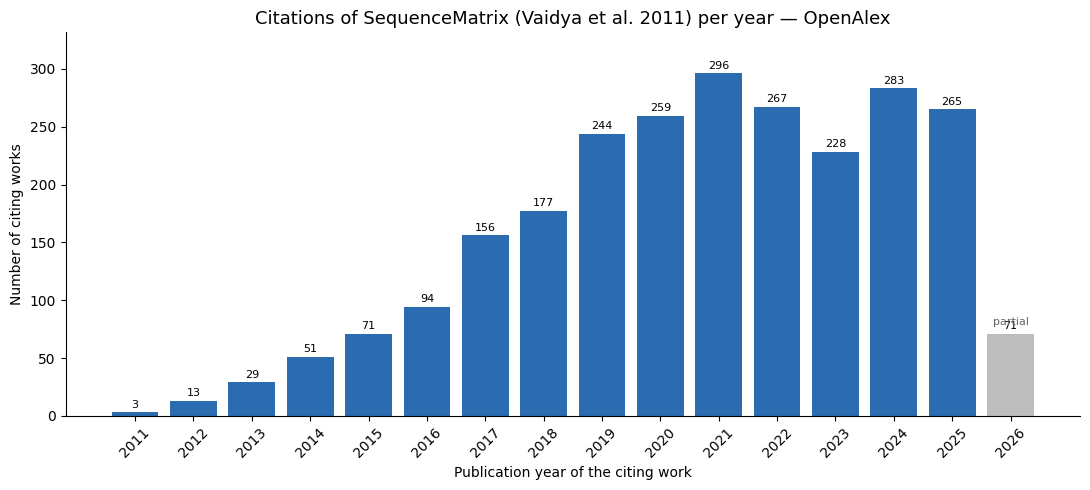

Total since 2011: 2,507 citing works
Mean over all complete years 2011–2025: 162/yr
Mean over the last 5 complete years 2021–2025: 268/yr  (no decline 15 years on)


In [2]:
per_year = (
    df["publication_year"]
    .dropna()
    .loc[lambda s: s >= PAPER_YEAR]   # 2 stray 2010 "early view" records pre-date publication
    .value_counts()
    .sort_index()
)

CURRENT_YEAR = int(per_year.index.max())  # 2026 — partial year, fetched mid-May
colors = ["#bdbdbd" if y == CURRENT_YEAR else "#2b6cb0" for y in per_year.index]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(per_year.index.astype(int), per_year.values, color=colors)
ax.bar_label(bars, padding=2, fontsize=8)

ax.set_title("Citations of SequenceMatrix (Vaidya et al. 2011) per year — OpenAlex", fontsize=13)
ax.set_xlabel("Publication year of the citing work")
ax.set_ylabel("Number of citing works")
ax.set_xticks(per_year.index.astype(int))
ax.tick_params(axis="x", rotation=45)
ax.margins(y=0.12)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

ax.text(
    CURRENT_YEAR, per_year.loc[CURRENT_YEAR] + 6,
    "partial", ha="center", va="bottom", fontsize=8, color="#666",
)
fig.tight_layout()
plt.show()

complete = per_year.loc[:CURRENT_YEAR - 1]
recent = complete.loc[CURRENT_YEAR - 5:]  # last 5 complete years — the proposal window
print(f"Total since {PAPER_YEAR}: {int(per_year.sum()):,} citing works")
print(f"Mean over all complete years {PAPER_YEAR}–{CURRENT_YEAR - 1}: {complete.mean():.0f}/yr")
print(f"Mean over the last 5 complete years {CURRENT_YEAR - 5}–{CURRENT_YEAR - 1}: "
      f"{recent.mean():.0f}/yr  (no decline 15 years on)")

## Top 10 journals and top 10 authors

**Journals** are counted one row per paper. **Authors** are counted once per paper
they appear on — so the leaders are people who repeatedly publish multi-gene
phylogenies, the bread-and-butter SequenceMatrix workflow.

In [3]:
def split_multi(series):
    """Explode a "; "-joined column into one tidy value per row, dropping blanks."""
    return (
        series.dropna()
        .str.split(";")
        .explode()
        .str.strip()
        .loc[lambda s: s.ne("")]
    )

In [4]:
top_journals = (
    df.loc[df["venue_type"].eq("journal"), "venue_name"]
    .dropna()
    .value_counts()
    .head(10)
    .rename_axis("Journal")
    .reset_index(name="Citing papers")
)
top_journals.index += 1
top_journals

,Journal,Citing papers
1,MycoKeys,118
2,Molecular Phylogenetics and Evolution,101
3,Scientific Reports,69
4,Mitochondrial DNA Part B,66
5,PLoS ONE,58
6,Zoological Journal of the Linnean Society,58
7,Systematic Entomology,51
8,Zoologica Scripta,48
9,Journal of Fungi,44
10,Frontiers in Microbiology,36


In [5]:
top_authors = (
    split_multi(df["author_names"])
    .value_counts()
    .head(10)
    .rename_axis("Author")
    .reset_index(name="Citing papers")
)
top_authors.index += 1
top_authors

,Author,Citing papers
1,Kevin D. Hyde,64
2,Qiang Li,40
3,Gonzalo Giribet,30
4,Qi Zhao,30
5,Ruvishika S. Jayawardena,28
6,Zong-Long Luo,28
7,Yong Wang,24
8,Łukasz Michalczyk,24
9,Jian‐Kui Liu,22
10,Yong‐Zhong Lu,22


## Word cloud of citing-paper titles

A quick qualitative read on *what kind of study* cites SequenceMatrix. We strip
generic research-paper filler ("new", "study", "analysis", "based", …) so the
domain signal — *phylogeny / phylogenetic, species, genus, genetic, molecular,
mitochondrial* — comes through. This is impressionistic; the curated topic and
software-co-mention breakdowns in
[`phase2_metadata.md`](phase2_metadata.md) are the rigorous version.

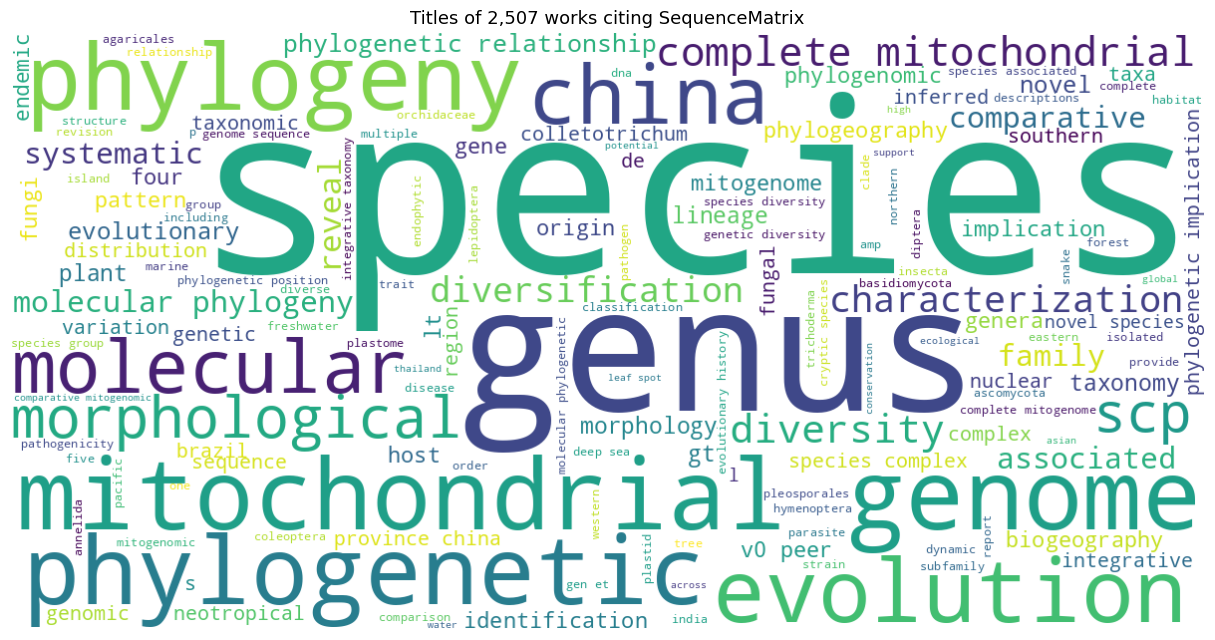

In [6]:
from wordcloud import STOPWORDS, WordCloud

# Domain-agnostic filler that would otherwise dominate any biology corpus.
EXTRA_STOPWORDS = {
    "new", "study", "studies", "analysis", "analyses", "based", "using", "use",
    "data", "first", "record", "records", "note", "notes", "description",
    "two", "three", "within", "reveals", "revealed", "insights", "evidence",
    "case", "sp", "nov", "n", "spp", "approach", "review", "results",
}
stopwords = set(STOPWORDS) | EXTRA_STOPWORDS

titles = " ".join(df["title"].dropna().astype(str)).lower()

wc = WordCloud(
    width=1200, height=600, background_color="white",
    stopwords=stopwords, collocations=True, colormap="viridis",
    max_words=150, prefer_horizontal=0.9, random_state=42,
).generate(titles)

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title(f"Titles of {df['title'].notna().sum():,} works citing SequenceMatrix", fontsize=13)
fig.tight_layout()
plt.show()

## Where to go next

This notebook covers the metadata-only picture (Phases 1–2). The repo also has:

- **Full-text coverage** — 69% of the corpus is reachable for free
  ([`data/fulltext/coverage.csv`](data/fulltext/coverage.csv)); see Phase 3a in
  [`README.md`](README.md#phase-3a-results-full-text-coverage-table-done-2026-05-25).
- **Software co-mentions** — which tools appear alongside SequenceMatrix in the
  same papers (`software_comentions` column here; CZ cross-check in
  [`data/cz_software_mentions/`](data/cz_software_mentions/README.md)).
- **Planned LLM extraction** (Phase 4) of *how* each paper actually used the
  tool — see the phased plan in [`README.md`](README.md#phased-plan).